# MTH9877 — Assignment 3: Part E(i) — Competing Risks Framework

**Standalone notebook.** Requires `processed/survival_loans.parquet`, `processed/macro_monthly.parquet`.

Covers: EDA · Hazard intensity · Aalen-Johansen CIF · KM vs AJ bias · Stratified CIF · Cause-specific Cox · Fine-Gray subdistribution hazard.

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from lifelines import AalenJohansenFitter, KaplanMeierFitter, CoxPHFitter
warnings.filterwarnings("ignore")

# ── Colour palette (aligned with partner's utilities.MODEL_COLORS) ────────────
C_PRE  = "#2563EB"   # prepayment — partner's Cox blue
C_DEF  = "#DC2626"   # default    — partner's DeepCox red
C_CEN  = "#9CA3AF"   # censored   — partner's LogReg gray

BLUES3 = ["#1D4ED8", "#2563EB", "#93C5FD"]
REDS3  = ["#991B1B", "#DC2626", "#FCA5A5"]

# Model colours for comparison tables (partner's palette)
MODEL_COLORS = {
    "LogReg":    "#9CA3AF",
    "RF":        "#16A34A",
    "LGBM":      "#EA580C",
    "Cox":       "#2563EB",
    "LinearCox": "#7C3AED",
    "DeepCox":   "#DC2626",
}

# ── Paths ─────────────────────────────────────────────────────────────────────
SURVIVAL_PATH = Path("processed/survival_loans.parquet")
MACRO_PATH    = Path("processed/macro_monthly.parquet")
OUT_DIR       = Path("processed")

# ── Partner A-D paths ─────────────────────────────────────────────────────────
ATOD_BASE        = Path("AtoD")
ATOD_SURVIVAL    = ATOD_BASE / "survival_table.parquet"
ATOD_B_HRS_BASE  = ATOD_BASE / "results_b/hazard_ratios_base.parquet"
ATOD_B_HRS_MACRO = ATOD_BASE / "results_b/hazard_ratios_macro.parquet"

# Part B concordance benchmarks (from partner's results)
PARTB_CI_BASE  = 0.6257   # base Cox (15 covariates, full training set)
PARTB_CI_MACRO = 0.6428   # macro Cox (+4 FRED variables)

# ── Plot style — aligned with partner's apply_plot_style() ───────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   12,
    "legend.fontsize":  10,
    "figure.dpi":       150,
})

## Setup

Loads `processed/survival_loans.parquet` and `processed/macro_monthly.parquet`, then draws a **5% stratified subsample** (~1.7M loans) stratified by vintage year. The full 34M-loan dataset is used only for EDA aggregations (via Polars lazy evaluation).

In [2]:
# ── Survival dataset + 5% stratified subsample ──────────────────────────────
survival = pl.read_parquet(SURVIVAL_PATH)
print(f"Full dataset : {survival.height:,} loans")

B_SAMPLE_N = int(0.05 * survival.height)  # 5% stratified by vintage year
sv_sub = (
    survival
    .with_columns(pl.col("VintageYear").cast(pl.Int32))
    .group_by("VintageYear")
    .map_groups(lambda g: g.sample(
        n=min(len(g), max(1, int(B_SAMPLE_N * len(g) / survival.height))),
        seed=42
    ))
).to_pandas()
print(f"Subsample    : {len(sv_sub):,} loans  (stratified by vintage year)")

# ── Merge delinquency history from partner's survival_table ──────────────────
# MaxDelinquency and EverDelinquent90Plus capture credit stress that the
# standard FICO+LTV features miss; partner's Part B confirmed these as
# leading indicators of default risk (HR > 2 in their base Cox model).
# Note: these are retrospective measures over the full loan life — suitable
# for competing-risks decomposition but not for out-of-sample forecasting.
_delinq = pl.read_parquet(
    ATOD_SURVIVAL,
    columns=["LoanSequenceNumber", "MaxDelinquency", "EverDelinquent90Plus"],
)
sv_sub = sv_sub.merge(
    _delinq.to_pandas(),
    on="LoanSequenceNumber",
    how="left",
)
sv_sub["MaxDelinquency"]   = sv_sub["MaxDelinquency"].fillna(0).clip(0, 12).astype(float)
sv_sub["EverDelinquent90"] = sv_sub["EverDelinquent90Plus"].fillna(0).astype(float)
print(f"EverDelinquent90+ rate : {sv_sub['EverDelinquent90'].mean():.2%}")

# ── Macro covariates ──────────────────────────────────────────────────────────
macro = pl.read_parquet(MACRO_PATH)
print(f"Macro rows   : {macro.height:,}  columns: {macro.columns}")

Full dataset : 34,013,469 loans
Subsample    : 1,700,662 loans  (stratified by vintage year)
EverDelinquent90+ rate : 4.88%
Macro rows   : 324  columns: ['yyyymm', 'mortgage_rate', 'unemployment', 'cpi_yoy', 'hpi_yoy']


## E(i) — Competing Risks Framework

Use the **Aalen-Johansen estimator** for cumulative incidence functions (CIF).
Unlike Kaplan-Meier `1 − S(t)`, AJ correctly handles competing risks:
treating default as a competing event for prepayment (and vice versa) avoids
over-estimating each CIF by naively censoring the other event.

Event codes: prepayment = 1, default = 2, censored = 0.

Sub-analyses: (a) EDA, (b) Aalen-Johansen CIF, (c) KM vs AJ bias,
(d) Stratified CIF, (e) Cause-Specific Cox, (f) Fine-Gray.

### (a) Exploratory Data Analysis

Before fitting any models, examine how prepayment, default, and censored loans
differ across key loan characteristics: duration, FICO, LTV, coupon rate, DTI,
loan purpose, and occupancy status.

In [3]:
# ── Build event labels on the full 34M-loan dataset (Polars) ─────────────────
surv_full = survival.with_columns([
    pl.when(pl.col("prepaid")   == 1).then(pl.lit("Prepaid"))
      .when(pl.col("defaulted") == 1).then(pl.lit("Defaulted"))
      .otherwise(pl.lit("Censored"))
      .alias("event")
])
N_FULL = surv_full.height

EVT_ORDER  = ["Prepaid", "Defaulted", "Censored"]
EVT_COLORS = {"Prepaid": C_PRE, "Defaulted": C_DEF, "Censored": C_CEN}

# ── Summary statistics table ──────────────────────────────────────────────────
print(f"Full dataset: {N_FULL:,} loans")
print("=" * 90)
print(f"{'':12} {'N':>10}  {'Share':>6}  {'Med dur':>8}  "
      f"{'FICO':>6}  {'LTV':>6}  {'Rate':>6}  {'DTI':>6}  {'UPB $k':>8}  {'#Borr':>6}")
print("-" * 90)
for evt in EVT_ORDER:
    sub = surv_full.filter(pl.col("event") == evt)
    s = sub.select([
        pl.col("duration").median().alias("dur"),
        pl.col("CreditScore").cast(pl.Float64).mean().alias("fico"),
        pl.col("OriginalLoantoValueLTV").mean().alias("ltv"),
        pl.col("OriginalInterestRate").mean().alias("rate"),
        pl.col("OriginalDebttoIncomeRatio")
          .filter(pl.col("OriginalDebttoIncomeRatio") < 999).mean().alias("dti"),
        pl.col("OriginalUPB").mean().alias("upb"),
        pl.col("NumberofBorrowers").cast(pl.Float64).mean().alias("borr"),
    ]).to_pandas().iloc[0]
    n = sub.height
    print(f"  {evt:<10} {n:>10,}  {100*n/N_FULL:>5.1f}%  "
          f"{s['dur']:>7.0f}m  {s['fico']:>6.0f}  {s['ltv']:>6.1f}  "
          f"{s['rate']:>6.2f}  {s['dti']:>6.1f}  {s['upb']/1000:>8.0f}  {s['borr']:>6.2f}")
print("=" * 90)

Full dataset: 34,013,469 loans
                      N   Share   Med dur    FICO     LTV    Rate     DTI    UPB $k   #Borr
------------------------------------------------------------------------------------------
  Prepaid    21,970,748   64.6%       35m     739    73.9    5.39    34.2       212    1.59
  Defaulted     532,563    1.6%       60m     695    82.5    6.24    38.8       170    1.41
  Censored   11,510,158   33.8%       30m     748    75.0    4.37    35.5       281    1.47


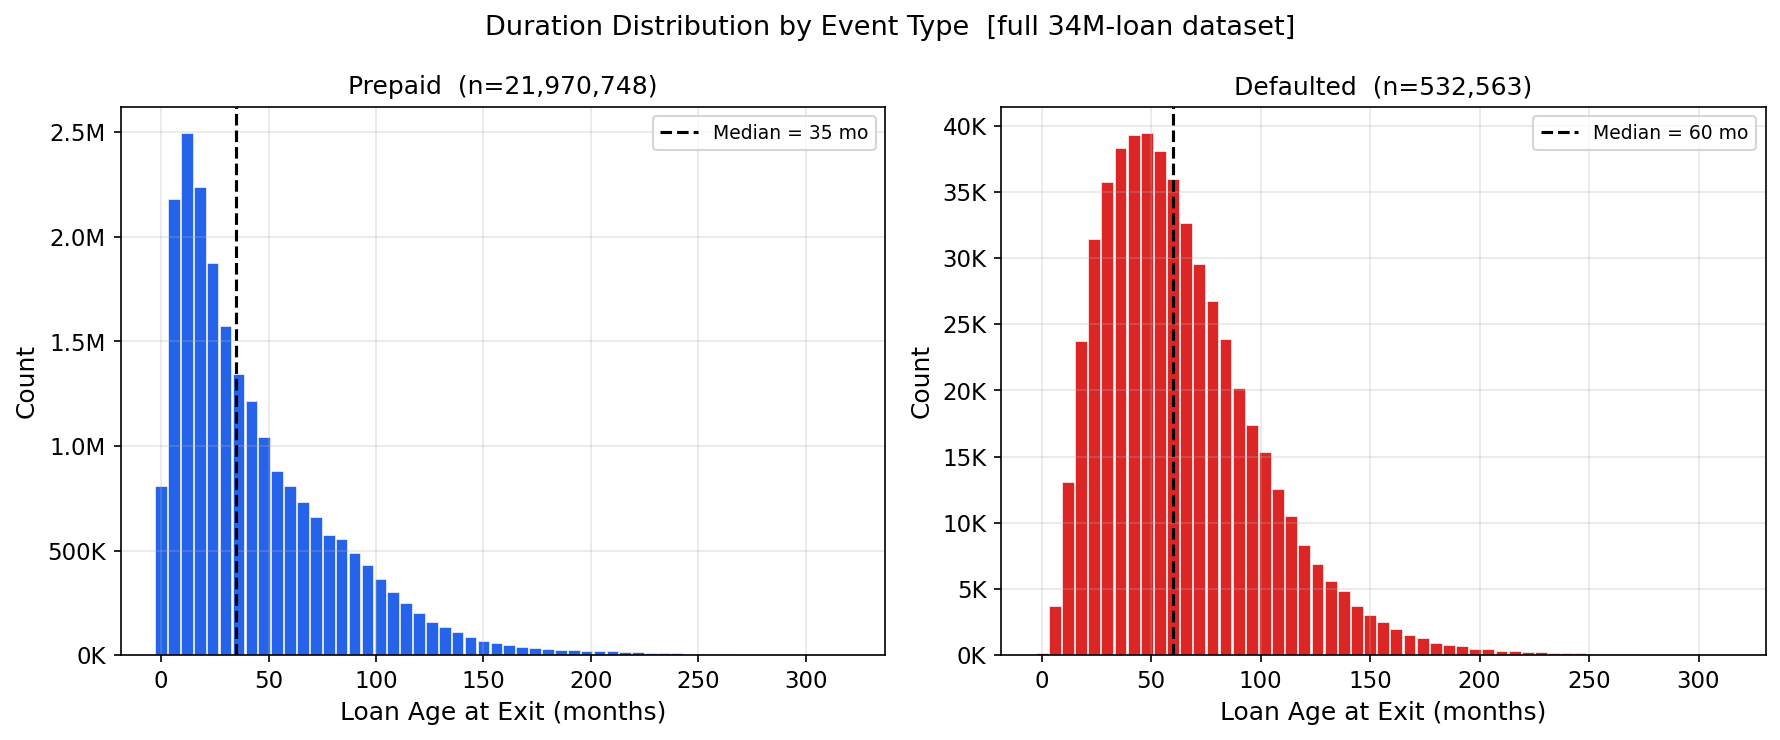

In [4]:
# ── Duration histograms: Prepaid and Defaulted ────────────────────────────────
BIN_W = 6
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, evt in zip(axes, ["Prepaid", "Defaulted"]):
    sub  = surv_full.filter(pl.col("event") == evt)
    hist = (
        sub.with_columns((pl.col("duration") // BIN_W * BIN_W).alias("bin"))
           .group_by("bin").agg(pl.len().alias("n"))
           .sort("bin").to_pandas()
    )
    med = sub.select(pl.col("duration").median()).item()
    ax.bar(hist["bin"], hist["n"], width=BIN_W * 0.9,
           color=EVT_COLORS[evt], edgecolor="white", linewidth=0.3)
    ax.axvline(med, color="black", lw=1.5, ls="--", label=f"Median = {med:.0f} mo")
    ax.set_title(f"{evt}  (n={sub.height:,})", fontsize=12)
    ax.set_xlabel("Loan Age at Exit (months)")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
    ax.legend(fontsize=9)
plt.suptitle("Duration Distribution by Event Type  [full 34M-loan dataset]", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "E1_eda_duration.png", dpi=150, bbox_inches="tight")
plt.show()

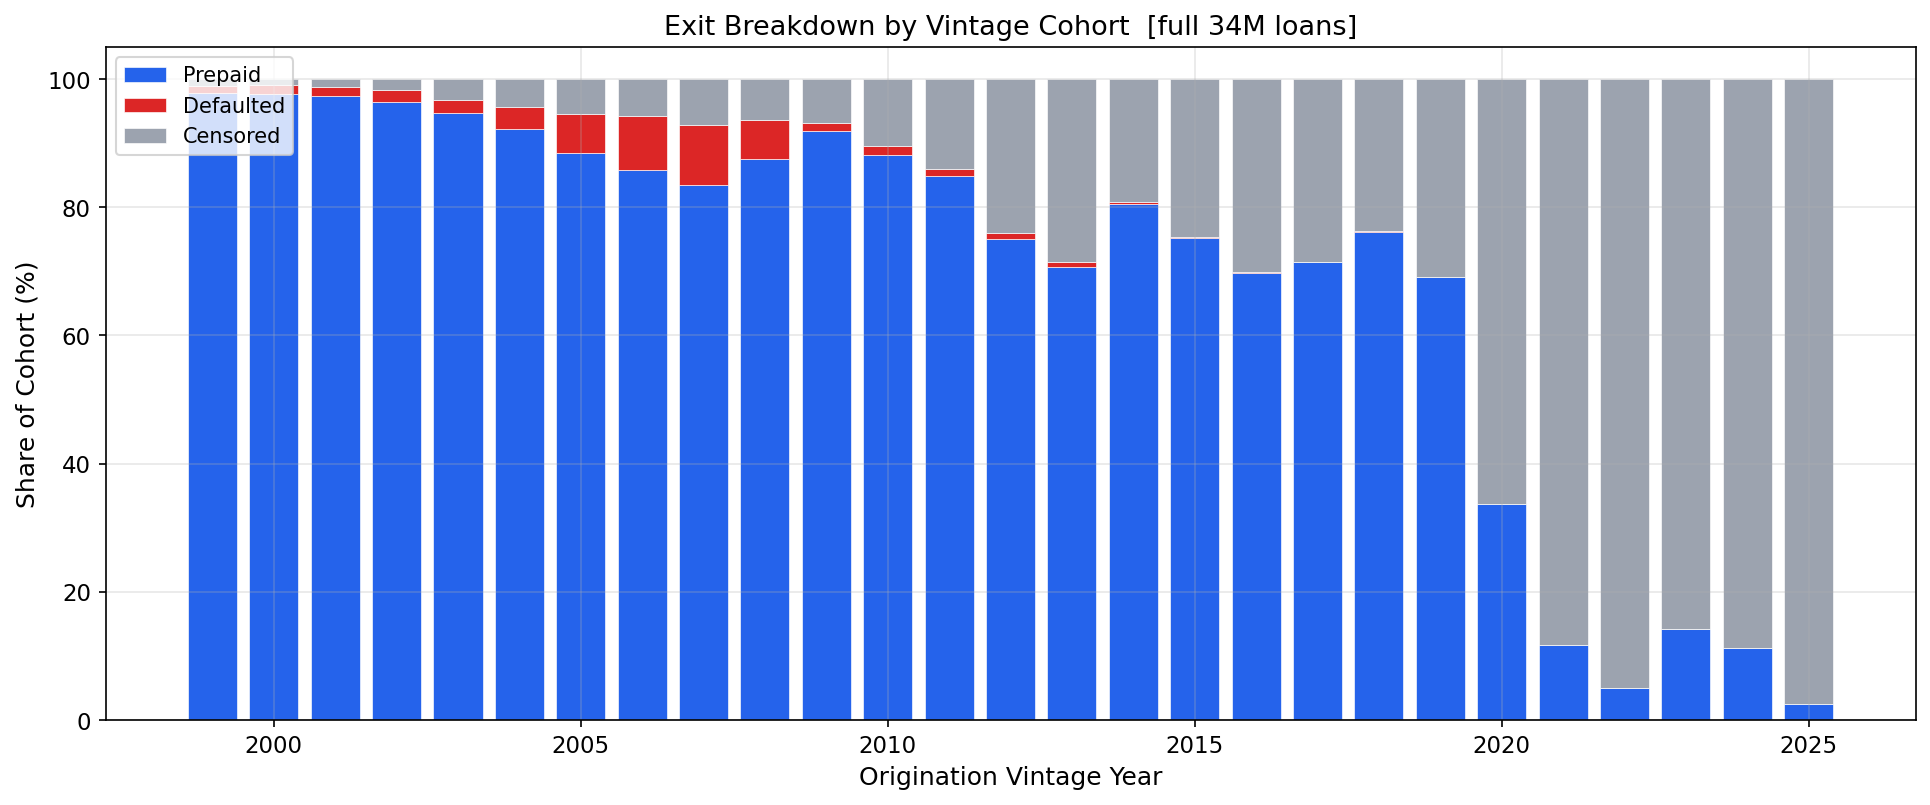

Peak default vintage   : 2007  (9.4%)
Median prepay duration : 35 months
Median default duration: 60 months
Mean FICO: Prepaid=739  Defaulted=695  Δ=44 pts
Mean LTV:  Prepaid=73.9%  Defaulted=82.5%  Δ=8.7 pts
Mean UPB:  Prepaid=$212K  Defaulted=$170K


In [5]:
# ── Exit breakdown by vintage cohort ─────────────────────────────────────────
cohort = (
    surv_full.group_by(["VintageYear", "event"])
    .agg(pl.len().alias("n"))
    .to_pandas()
    .pivot(index="VintageYear", columns="event", values="n")
    .fillna(0)
    .reindex(columns=EVT_ORDER, fill_value=0)
    .sort_index()
)
cohort_pct   = cohort.div(cohort.sum(axis=1), axis=0) * 100
default_rate = cohort_pct["Defaulted"]

fig, ax = plt.subplots(figsize=(13, 5.5))
bottom = np.zeros(len(cohort_pct))
for evt in EVT_ORDER:
    ax.bar(cohort_pct.index, cohort_pct[evt], bottom=bottom,
           color=EVT_COLORS[evt], label=evt, edgecolor="white", linewidth=0.3)
    bottom += cohort_pct[evt].values
ax.set_xlabel("Origination Vintage Year")
ax.set_ylabel("Share of Cohort (%)")
ax.set_title("Exit Breakdown by Vintage Cohort  [full 34M loans]")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(OUT_DIR / "E1_eda_vintage.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Key observations ──────────────────────────────────────────────────────────
peak_yr  = default_rate.idxmax()
pre_med  = surv_full.filter(pl.col("event")=="Prepaid").select(pl.col("duration").median()).item()
def_med  = surv_full.filter(pl.col("event")=="Defaulted").select(pl.col("duration").median()).item()
fico_pre = surv_full.filter(pl.col("event")=="Prepaid").select(pl.col("CreditScore").cast(pl.Float64).mean()).item()
fico_def = surv_full.filter(pl.col("event")=="Defaulted").select(pl.col("CreditScore").cast(pl.Float64).mean()).item()
ltv_pre  = surv_full.filter(pl.col("event")=="Prepaid").select(pl.col("OriginalLoantoValueLTV").mean()).item()
ltv_def  = surv_full.filter(pl.col("event")=="Defaulted").select(pl.col("OriginalLoantoValueLTV").mean()).item()
upb_pre  = surv_full.filter(pl.col("event")=="Prepaid").select(pl.col("OriginalUPB").mean()).item()
upb_def  = surv_full.filter(pl.col("event")=="Defaulted").select(pl.col("OriginalUPB").mean()).item()
print(f"Peak default vintage   : {peak_yr}  ({default_rate[peak_yr]:.1f}%)")
print(f"Median prepay duration : {pre_med:.0f} months")
print(f"Median default duration: {def_med:.0f} months")
print(f"Mean FICO: Prepaid={fico_pre:.0f}  Defaulted={fico_def:.0f}  Δ={fico_pre-fico_def:.0f} pts")
print(f"Mean LTV:  Prepaid={ltv_pre:.1f}%  Defaulted={ltv_def:.1f}%  Δ={ltv_def-ltv_pre:.1f} pts")
print(f"Mean UPB:  Prepaid=${upb_pre/1000:.0f}K  Defaulted=${upb_def/1000:.0f}K")

### (b) Aalen-Johansen Cumulative Incidence Functions

#### Kaplan-Meier (incorrect under competing risks)

$$\hat{S}_{KM}(t) = \prod_{t_i \leq t}\left(1 - \frac{d_i^{(k)}}{n_i}\right), \qquad \hat{F}_{KM}^{(k)}(t) = 1 - \hat{S}_{KM}(t)$$

where $d_i^{(k)}$ counts only **cause-$k$ events** — all other exits are treated as independent censorings. This overcounts the cause-$k$ hazard because competing-event loans are not randomly removed.

#### Aalen-Johansen estimator (correct)

$$\boxed{\hat{F}_k(t) = \sum_{t_j \leq t} \hat{S}(t_j^{-})\cdot\frac{d_{kj}}{n_j}}$$

| Symbol | Meaning |
|---|---|
| $\hat{F}_k(t)$ | Cumulative Incidence Function for cause $k$ at loan age $t$ |
| $d_{kj}$ | Number of cause-$k$ exits at time $t_j$ |
| $n_j$ | Loans at risk just before $t_j$ |
| $\hat{S}(t_j^{-})$ | Overall survival just before $t_j$: uses **all** exits $d_j = \sum_k d_{kj}$ |

The key difference: AJ weights each increment by $\hat{S}(t_j^-)$, the probability of still being in the risk set. As loans leave by *any* cause, this weight shrinks, preventing over-attribution to any single cause.

**Partition identity** (impossible under KM):
$$\sum_{k} \hat{F}_k(t) + \hat{S}(t) = 1$$

Fit AJ jointly on both causes using the 5% stratified subsample.

Competing risks sample: 1,700,662 loans
  Prepaid  : 1,099,067
  Defaulted: 26,570
  Censored : 575,025


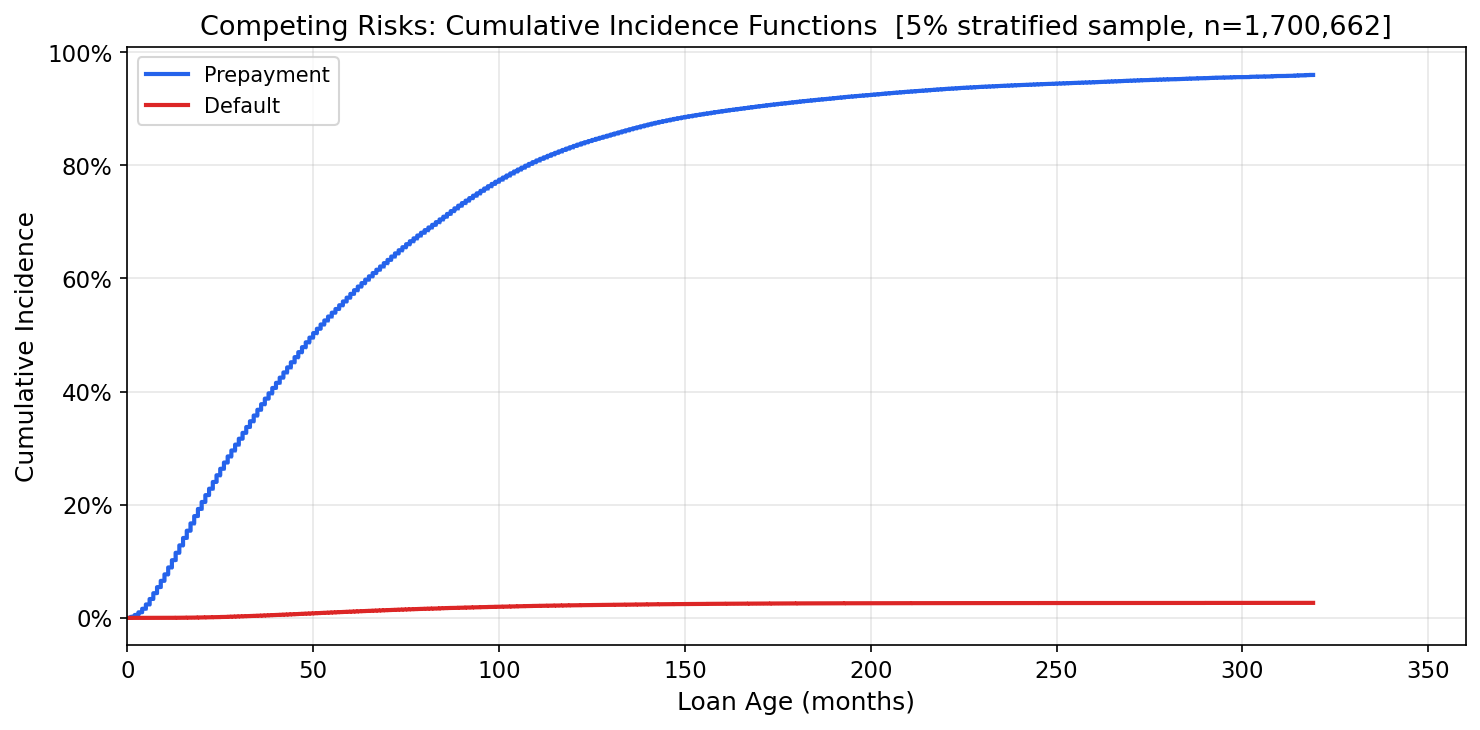

10-yr prepayment CIF : 0.833
10-yr default    CIF : 0.0223


In [6]:
sv_cr = sv_sub[["duration", "prepaid", "defaulted"]].copy()
sv_cr["event_type"] = 0
sv_cr.loc[sv_cr["prepaid"]   == 1, "event_type"] = 1
sv_cr.loc[sv_cr["defaulted"] == 1, "event_type"] = 2
print(f"Competing risks sample: {len(sv_cr):,} loans")
print(f"  Prepaid  : {(sv_cr['event_type']==1).sum():,}")
print(f"  Defaulted: {(sv_cr['event_type']==2).sum():,}")
print(f"  Censored : {(sv_cr['event_type']==0).sum():,}")

T_cr = sv_cr["duration"]
E_cr = sv_cr["event_type"]

fig, ax = plt.subplots(figsize=(10, 5))

ajf_prepay = AalenJohansenFitter()
ajf_prepay.fit(T_cr, E_cr, event_of_interest=1)
ajf_prepay.plot_cumulative_density(ax=ax, color=C_PRE, lw=2, label="Prepayment")

ajf_default = AalenJohansenFitter()
ajf_default.fit(T_cr, E_cr, event_of_interest=2)
ajf_default.plot_cumulative_density(ax=ax, color=C_DEF, lw=2, label="Default")

ax.set_xlabel("Loan Age (months)")
ax.set_ylabel("Cumulative Incidence")
ax.set_title(f"Competing Risks: Cumulative Incidence Functions  [5% stratified sample, n={len(sv_cr):,}]")
ax.set_xlim(0, 360)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "E1_competing_risks_cif.png", dpi=150, bbox_inches="tight")
plt.show()

col_p = ajf_prepay.cumulative_density_.columns[0]
col_d = ajf_default.cumulative_density_.columns[0]
print(f"10-yr prepayment CIF : {ajf_prepay.cumulative_density_[col_p].loc[120]:.3f}")
print(f"10-yr default    CIF : {ajf_default.cumulative_density_[col_d].loc[120]:.4f}")


### Aalen-Johansen CIF — Results

The Aalen-Johansen estimator decomposes the total exit probability into two
competing causes:

- **Prepayment** dominates: the 10-yr CIF is **83.3%**, reflecting multiple refinancing cycles
  across 1999–2020+ vintages. The Freddie Mac portfolio includes many loans that prepaid
  opportunistically through 2003–2004 and 2020–2021 rate cycles.
- **Default** is rare: the 10-yr CIF is **2.23%**, concentrated in 2006–2010 vintages (peak 9.4%
  default rate for the 2007 cohort).
- The curves **sum to ~85.5%** — the remaining 14.5% is right-censored loans still active at
  the analysis date (recent vintages with short observation windows).

Note: Aalen-Johansen CIF < KM `1 − S(t)` for each cause — the KM formula
over-estimates by treating competing events as independent censorings. The bias
is modest here (+1.3 pp at 10 yr, +2.2 pp at 20 yr) because default is rare (1.6%),
so the competing-risk distortion is small.

### (c) KM vs AJ — Bias from Ignoring Competing Events

#### Why KM over-estimates the CIF

Under KM, defaulted loans are treated as **independent censored** observations at their exit time. In practice they are **not** independent: they are systematically the riskier loans that would have been *less likely* to prepay. Removing them inflates the estimated prepayment hazard.

Formally, at each event time $t_j$ the KM increment is:

$$\Delta\hat{F}_{KM}^{(\text{pre})}(t_j) = \hat{S}_{KM}(t_j^-)\cdot\frac{d_{1j}}{n_j^{\text{KM}}}$$

where $n_j^{\text{KM}}$ **excludes** prior defaults from the denominator — they were "censored away."

The AJ increment at the same time is:

$$\Delta\hat{F}_{AJ}^{(\text{pre})}(t_j) = \hat{S}(t_j^-)\cdot\frac{d_{1j}}{n_j}$$

Because $\hat{S}(t_j^-) \leq \hat{S}_{KM}(t_j^-)$ (overall survival is always lower than cause-specific), every AJ increment is $\leq$ the KM increment, so:

$$\hat{F}_{AJ}^{(\text{pre})}(t) \leq \hat{F}_{KM}^{(\text{pre})}(t) \quad \text{for all } t$$

The gap widens over time as the competing cause removes more loans from the risk set.

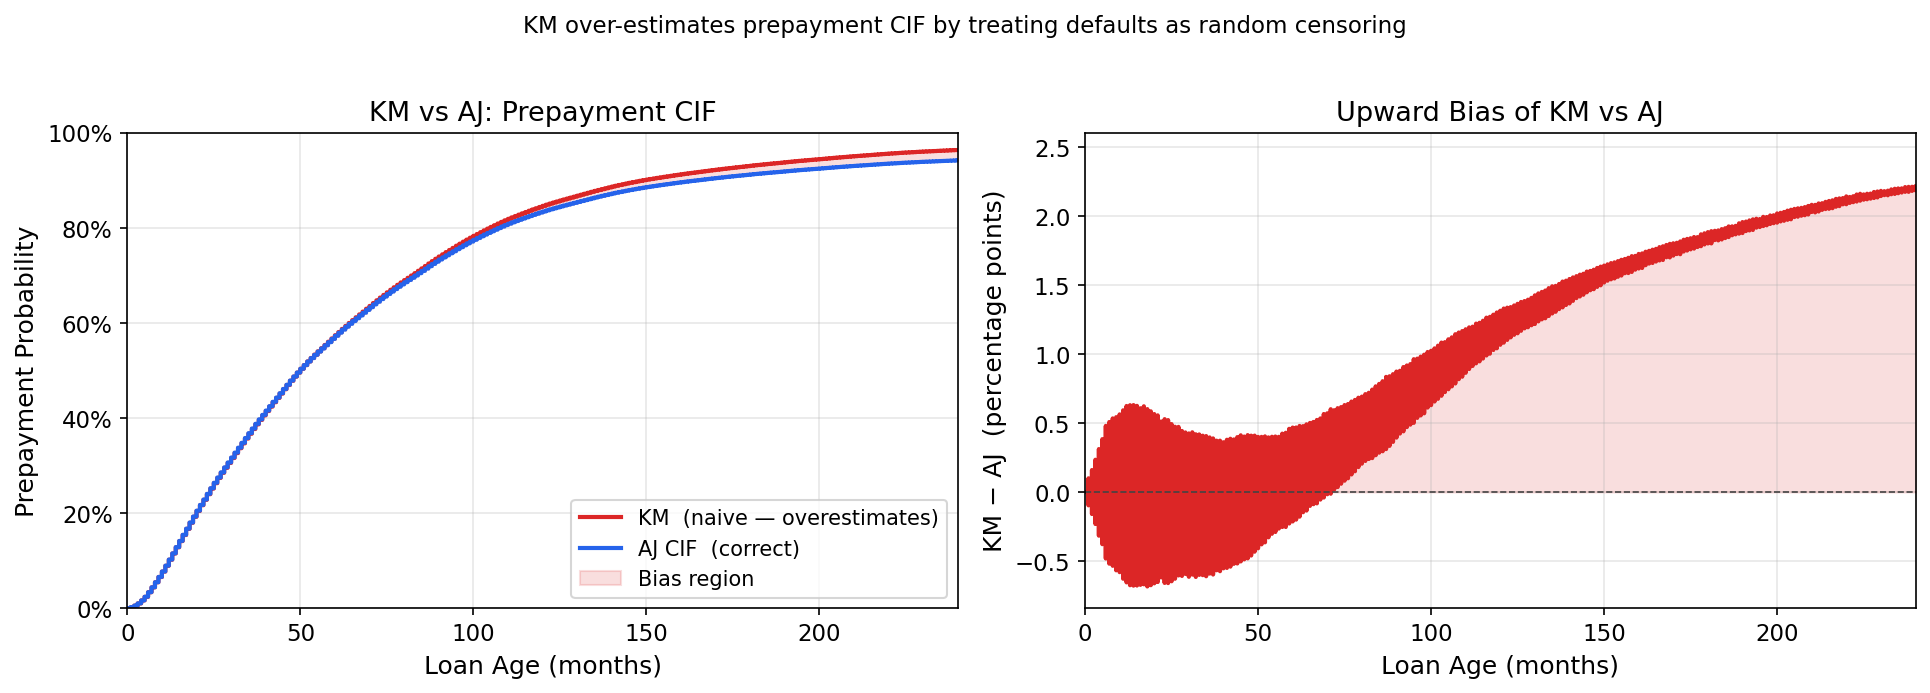

   Horizon        KM        AJ   Bias (pp)
        60     0.574     0.569       +0.47
       120     0.846     0.833       +1.31
       240     0.964     0.942       +2.22


In [7]:
kmf = KaplanMeierFitter()
kmf.fit(sv_cr["duration"], event_observed=(sv_cr["event_type"] == 1),
        label="KM 1−S(t)  [treats default as censored]")

col_p = ajf_prepay.cumulative_density_.columns[0]
km_cdf = 1 - kmf.survival_function_["KM 1−S(t)  [treats default as censored]"]

common_t = ajf_prepay.cumulative_density_.index
km_interp = km_cdf.reindex(common_t, method="ffill").fillna(0)
aj_interp = ajf_prepay.cumulative_density_[col_p].reindex(common_t, method="ffill").fillna(0)
bias      = km_interp - aj_interp

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: KM vs AJ overlay
axes[0].step(common_t, km_interp, where="post", color=C_DEF, lw=2,
             label="KM  (naive — overestimates)")
axes[0].step(common_t, aj_interp, where="post", color=C_PRE, lw=2,
             label="AJ CIF  (correct)")
axes[0].fill_between(common_t, aj_interp, km_interp, alpha=0.15,
                     color=C_DEF, step="post", label="Bias region")
axes[0].set_xlim(0, 240); axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[0].set_xlabel("Loan Age (months)"); axes[0].set_ylabel("Prepayment Probability")
axes[0].set_title("KM vs AJ: Prepayment CIF"); axes[0].legend()

# Right: bias over time
axes[1].step(common_t, bias * 100, where="post", color=C_DEF, lw=2)
axes[1].fill_between(common_t, 0, bias * 100, alpha=0.15, color=C_DEF, step="post")
axes[1].axhline(0, color="#444444", lw=0.8, ls="--")
axes[1].set_xlim(0, 240)
axes[1].set_xlabel("Loan Age (months)"); axes[1].set_ylabel("KM − AJ  (percentage points)")
axes[1].set_title("Upward Bias of KM vs AJ")

plt.suptitle("KM over-estimates prepayment CIF by treating defaults as random censoring",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "E1_km_vs_aj_bias.png", dpi=150, bbox_inches="tight")
plt.show()

horizons = [60, 120, 240]
print(f"{'Horizon':>10}  {'KM':>8}  {'AJ':>8}  {'Bias (pp)':>10}")
for h in horizons:
    t = common_t[common_t <= h][-1]
    print(f"{h:>10}  {km_interp[t]:>8.3f}  {aj_interp[t]:>8.3f}  {bias[t]*100:>+10.2f}")


### (d) Stratified CIF by Loan Characteristics

Does the prepayment/default balance shift across loan segments? We stratify by
three dimensions: FICO score, LTV bucket, and vintage era.

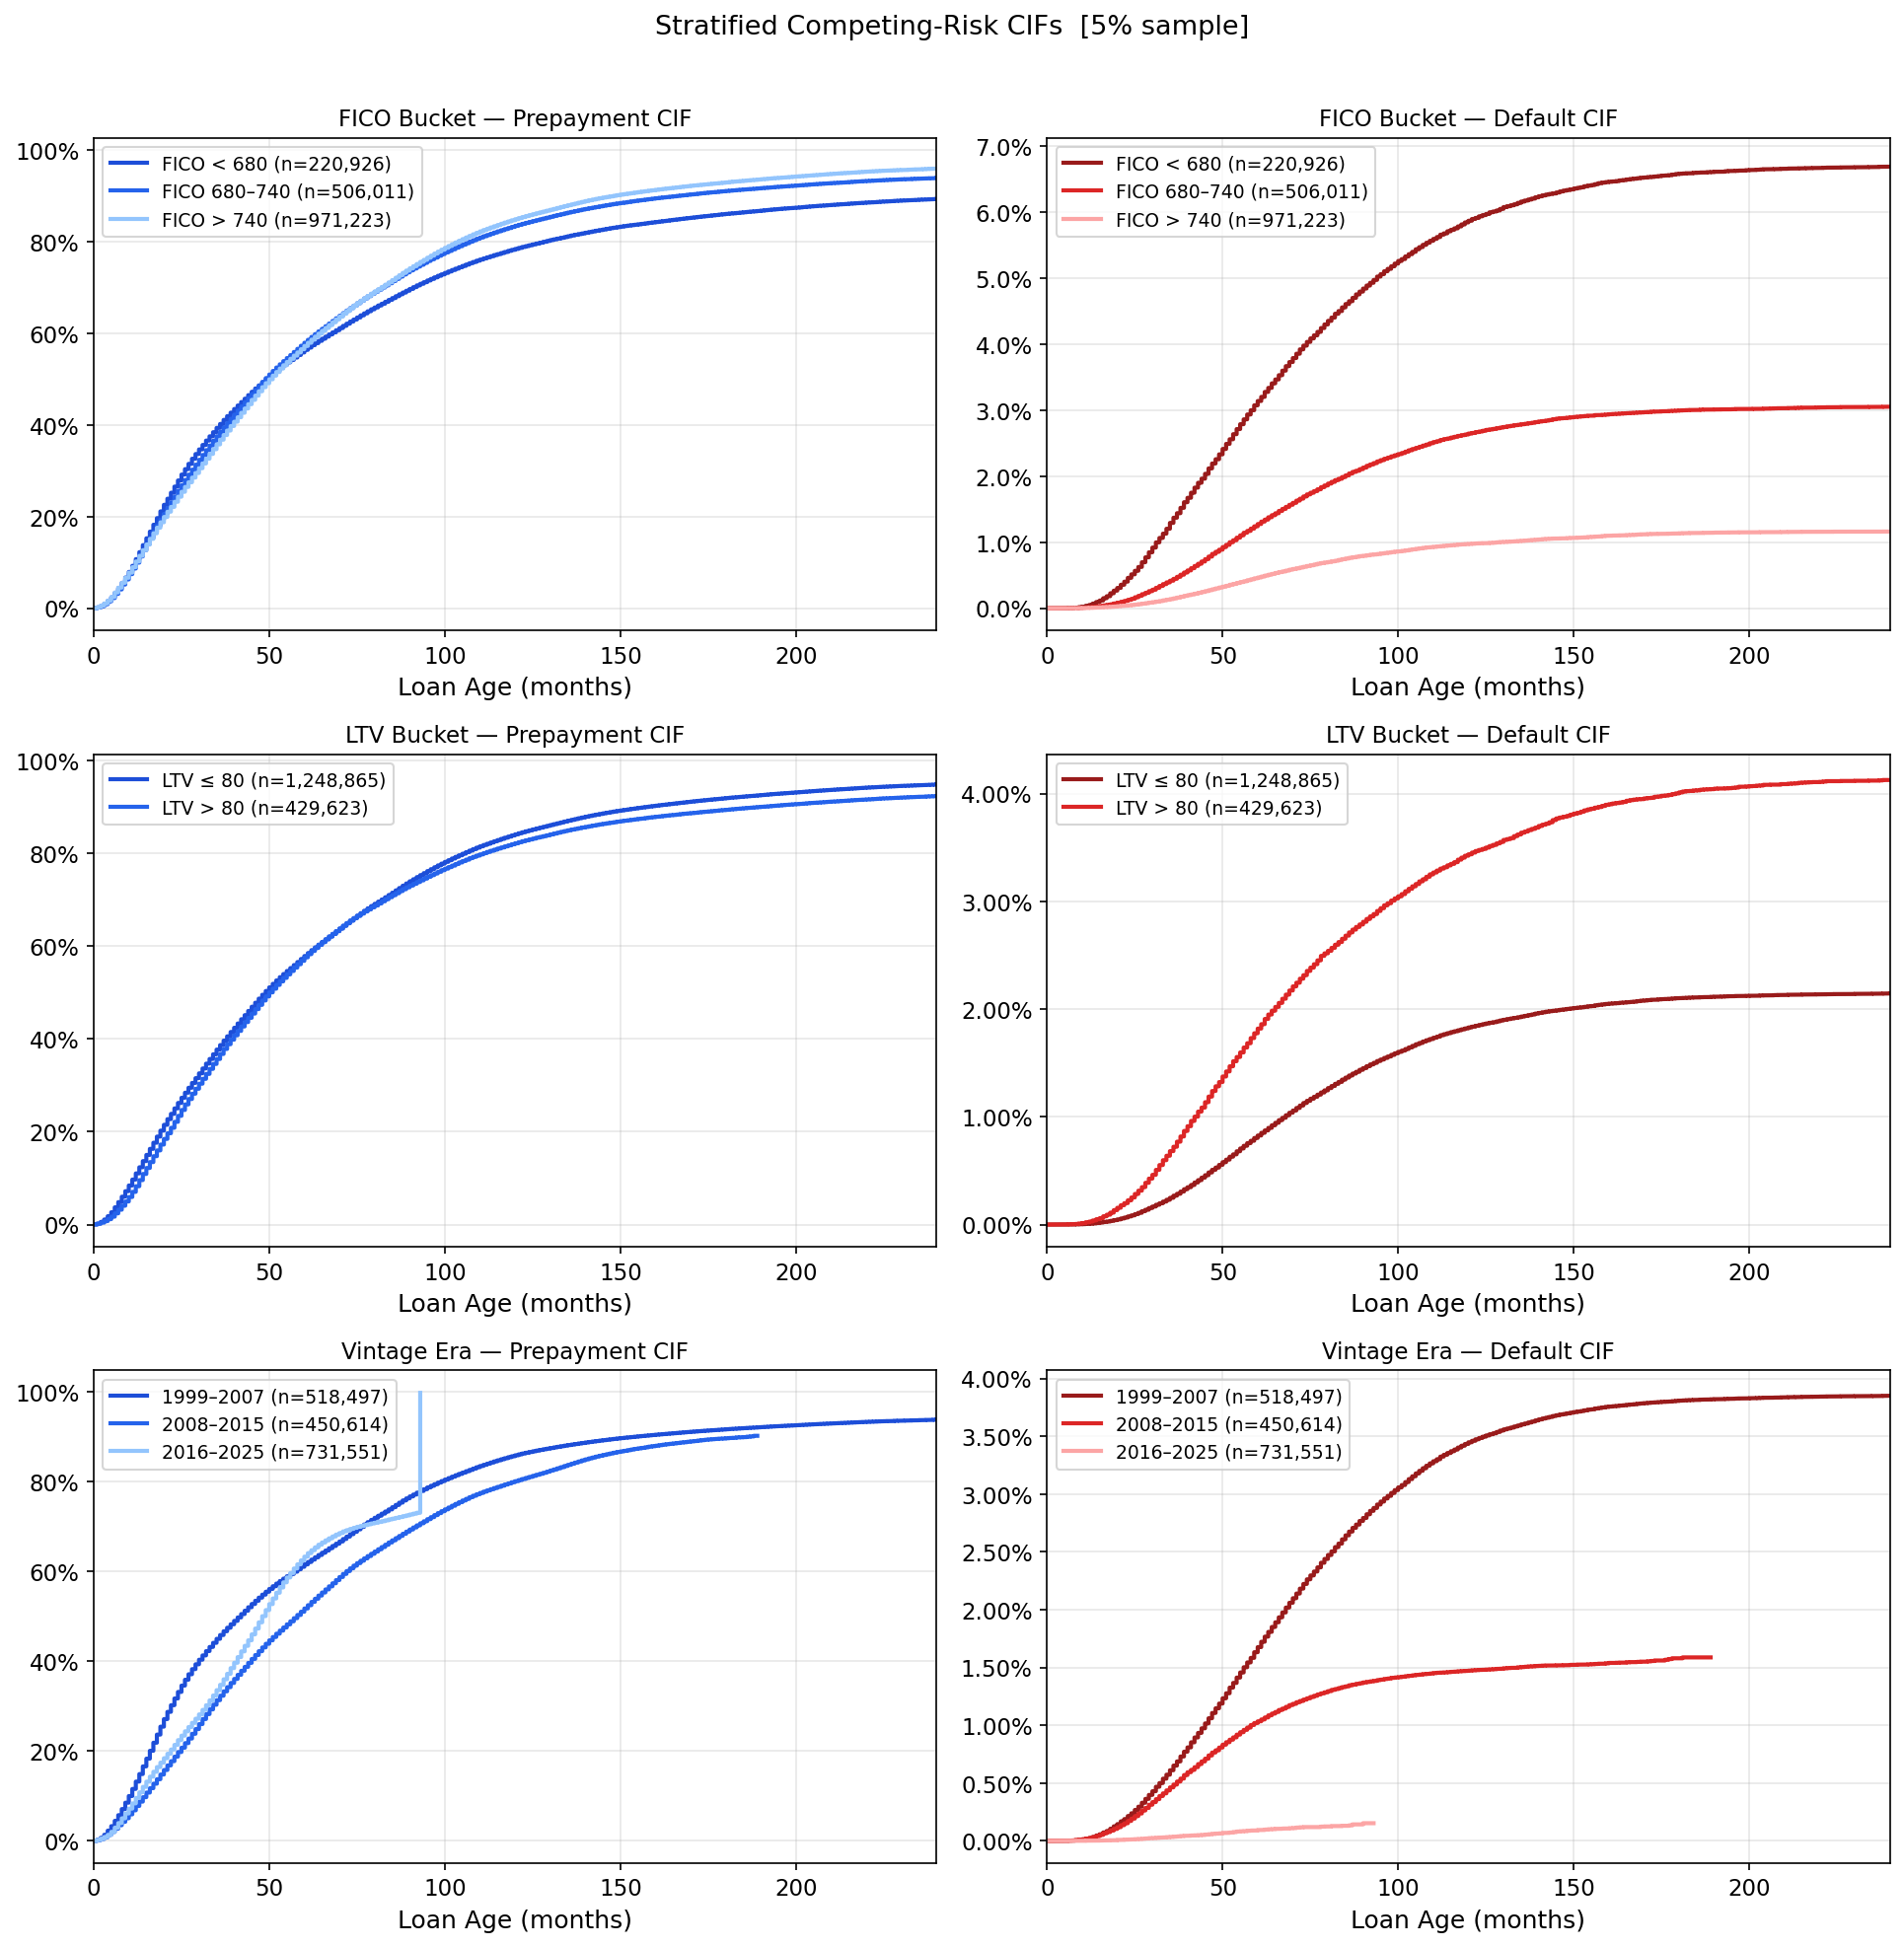

In [8]:
sv_cr2 = sv_sub[["duration", "prepaid", "defaulted",
                  "CreditScore", "OriginalLoantoValueLTV", "VintageYear"]].copy()
sv_cr2["event_type"] = 0
sv_cr2.loc[sv_cr2["prepaid"]   == 1, "event_type"] = 1
sv_cr2.loc[sv_cr2["defaulted"] == 1, "event_type"] = 2

sv_cr2["fico_grp"] = pd.cut(sv_cr2["CreditScore"],
                             bins=[0, 680, 740, 850],
                             labels=["FICO < 680", "FICO 680–740", "FICO > 740"])
sv_cr2["ltv_grp"]  = pd.cut(sv_cr2["OriginalLoantoValueLTV"],
                             bins=[0, 80, 100],
                             labels=["LTV ≤ 80", "LTV > 80"])
sv_cr2["vintage_grp"] = pd.cut(sv_cr2["VintageYear"],
                                bins=[1998, 2007, 2015, 2025],
                                labels=["1999–2007", "2008–2015", "2016–2025"])

strat_dims = [
    ("fico_grp",    ["FICO < 680", "FICO 680–740", "FICO > 740"],  "FICO Bucket",   BLUES3, REDS3),
    ("ltv_grp",     ["LTV ≤ 80", "LTV > 80"],                      "LTV Bucket",    BLUES3[:2], REDS3[:2]),
    ("vintage_grp", ["1999–2007", "2008–2015", "2016–2025"],        "Vintage Era",   BLUES3, REDS3),
]

fig, axes = plt.subplots(3, 2, figsize=(13, 13))

for row, (col, groups, title, clrs_pre, clrs_def) in enumerate(strat_dims):
    for cause, cause_label, ax, clrs in [
        (1, "Prepayment CIF", axes[row, 0], clrs_pre),
        (2, "Default CIF",    axes[row, 1], clrs_def),
    ]:
        for grp, clr in zip(groups, clrs):
            sub = sv_cr2[sv_cr2[col].astype(str) == str(grp)].dropna(subset=[col])
            if len(sub) < 50 or (sub["event_type"] == cause).sum() < 10:
                continue
            ajf = AalenJohansenFitter()
            ajf.fit(sub["duration"], sub["event_type"],
                    event_of_interest=cause, label=f"{grp} (n={len(sub):,})")
            ajf.plot_cumulative_density(ax=ax, ci_show=False, color=clr, lw=2)
        ax.set_title(f"{title} — {cause_label}", fontsize=11)
        ax.set_xlabel("Loan Age (months)"); ax.set_xlim(0, 240)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        ax.legend(fontsize=9)

plt.suptitle("Stratified Competing-Risk CIFs  [5% sample]", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "E1_stratified_cif.png", dpi=150, bbox_inches="tight")
plt.show()


### (e) Cause-Specific Cox Regression

Fit two separate Cox proportional-hazard models treating the *other* cause as censored:

- **Prepayment model**: default exits are censored at their exit time
- **Default model**: prepayment exits are censored at their exit time
- **Naive combined model**: any exit is the event (baseline for comparison)

Features: 9 numeric (credit, LTV, rates, macro at origination) +
4 one-hot (loan purpose × 2, occupancy × 2) = 13 total.

In [9]:
# ── Annual macro averages at origination vintage ──────────────────────────────
macro_annual = (
    macro.to_pandas()
    .assign(year=lambda df: df["yyyymm"] // 100)
    .groupby("year")[["mortgage_rate", "unemployment", "hpi_yoy"]]
    .mean()
    .reset_index()
)

# ── Feature matrix ────────────────────────────────────────────────────────────
cs_base = sv_sub[[
    "LoanSequenceNumber", "duration", "prepaid", "defaulted",
    "CreditScore", "OriginalLoantoValueLTV", "OriginalInterestRate",
    "OriginalDebttoIncomeRatio", "OriginalUPB", "VintageYear",
    "LoanPurpose", "OccupancyStatus",
    "MaxDelinquency", "EverDelinquent90",   # partner's Part B features
]].copy()
cs_base = cs_base.merge(macro_annual, left_on="VintageYear",
                        right_on="year", how="left").drop(columns="year")

# One-hot: baseline = LoanPurpose=C (cash-out refi), OccupancyStatus=P (primary)
cs_base["LP_Purchase"]    = (cs_base["LoanPurpose"] == "P").astype(float)
cs_base["LP_NoCashRefi"]  = (cs_base["LoanPurpose"] == "N").astype(float)
cs_base["Occ_Investment"] = (cs_base["OccupancyStatus"] == "I").astype(float)
cs_base["Occ_SecondHome"] = (cs_base["OccupancyStatus"] == "S").astype(float)
cs_base["rate_incentive"] = cs_base["OriginalInterestRate"] - cs_base["mortgage_rate"]
cs_base = cs_base.dropna()

NUMERIC_COLS = [
    "CreditScore", "OriginalLoantoValueLTV",
    "OriginalDebttoIncomeRatio", "OriginalUPB",
    "mortgage_rate", "unemployment", "hpi_yoy", "rate_incentive",
    "MaxDelinquency", "EverDelinquent90",   # ← from partner's Part B
]
CAT_COLS_OH = ["LP_Purchase", "LP_NoCashRefi", "Occ_Investment", "Occ_SecondHome"]
COX_COLS    = NUMERIC_COLS + CAT_COLS_OH

COL_LABELS = {
    "CreditScore":               "CreditScore",
    "OriginalLoantoValueLTV":    "LTV",
    "OriginalDebttoIncomeRatio": "DTI",
    "OriginalUPB":               "UPB",
    "mortgage_rate":             "Mortgage Rate (orig)",
    "unemployment":              "Unemployment (orig)",
    "hpi_yoy":                   "HPI YoY (orig)",
    "rate_incentive":            "Rate Incentive",
    "MaxDelinquency":            "Max Delinquency (mo)",
    "EverDelinquent90":          "Ever 90+ DQ",
    "LP_Purchase":               "LoanPurpose=Purchase",
    "LP_NoCashRefi":             "LoanPurpose=NoCashRefi",
    "Occ_Investment":            "Occupancy=Investment",
    "Occ_SecondHome":            "Occupancy=SecondHome",
}

cs_df = cs_base[COX_COLS + ["duration", "prepaid", "defaulted"]].copy()
cs_df["any_event"] = ((cs_df["prepaid"] == 1) | (cs_df["defaulted"] == 1)).astype(int)
cs_df[NUMERIC_COLS] = StandardScaler().fit_transform(cs_df[NUMERIC_COLS])

print(f"Cause-specific dataset: {len(cs_df):,} loans  "
      f"({cs_df['prepaid'].sum():,} prepaid, {cs_df['defaulted'].sum():,} defaulted)")
print(f"Features: {len(COX_COLS)}  ({len(NUMERIC_COLS)} numeric incl. delinquency + {len(CAT_COLS_OH)} categorical)")

Cause-specific dataset: 1,567,580 loans  (989,991 prepaid, 23,464 defaulted)
Features: 14  (10 numeric incl. delinquency + 4 categorical)


In [10]:
# ── Fit cause-specific Cox models ─────────────────────────────────────────────
print("Fitting Cox models (penalizer=0.1)...")
cph_prepay = CoxPHFitter(penalizer=0.1)
cph_prepay.fit(cs_df[COX_COLS + ["duration", "prepaid"]],
               duration_col="duration", event_col="prepaid")

cph_default = CoxPHFitter(penalizer=0.1)
cph_default.fit(cs_df[COX_COLS + ["duration", "defaulted"]],
                duration_col="duration", event_col="defaulted")

cph_combined = CoxPHFitter(penalizer=0.1)
cph_combined.fit(cs_df[COX_COLS + ["duration", "any_event"]],
                 duration_col="duration", event_col="any_event")
print("  Done.\n")

# ── Coefficient comparison table ──────────────────────────────────────────────
print(f"{'Covariate':<30} {'Naive':>8} {'Prepay':>8} {'Default':>9}  Note")
print("-" * 72)
for col in COX_COLS:
    naive   = cph_combined.params_[col]
    prepay  = cph_prepay.params_[col]
    default = cph_default.params_[col]
    flag = ("← opposite" if (prepay * default < 0 and
                              abs(prepay) > 0.05 and abs(default) > 0.05)
            else "← diverge" if abs(prepay - default) > 0.3 else "")
    lbl = COL_LABELS.get(col, col)
    print(f"  {lbl:<28} {naive:>+8.3f} {prepay:>+8.3f} {default:>+9.3f}  {flag}")

Fitting Cox models (penalizer=0.1)...
  Done.

Covariate                         Naive   Prepay   Default  Note
------------------------------------------------------------------------
  CreditScore                    +0.016   +0.010    -0.047  
  LTV                            -0.007   -0.011    +0.041  
  DTI                            -0.003   -0.004    +0.031  
  UPB                            +0.161   +0.161    -0.010  
  Mortgage Rate (orig)           +0.254   +0.250    +0.060  
  Unemployment (orig)            -0.111   -0.109    -0.039  
  HPI YoY (orig)                 -0.119   -0.119    -0.022  
  Rate Incentive                 +0.253   +0.256    +0.021  
  Max Delinquency (mo)           -0.123   -0.245    +0.298  ← opposite
  Ever 90+ DQ                    -0.035   -0.071    +0.270  ← opposite
  LoanPurpose=Purchase           +0.011   +0.013    -0.009  
  LoanPurpose=NoCashRefi         +0.047   +0.046    -0.013  
  Occupancy=Investment           -0.289   -0.297    +0.027  ← d

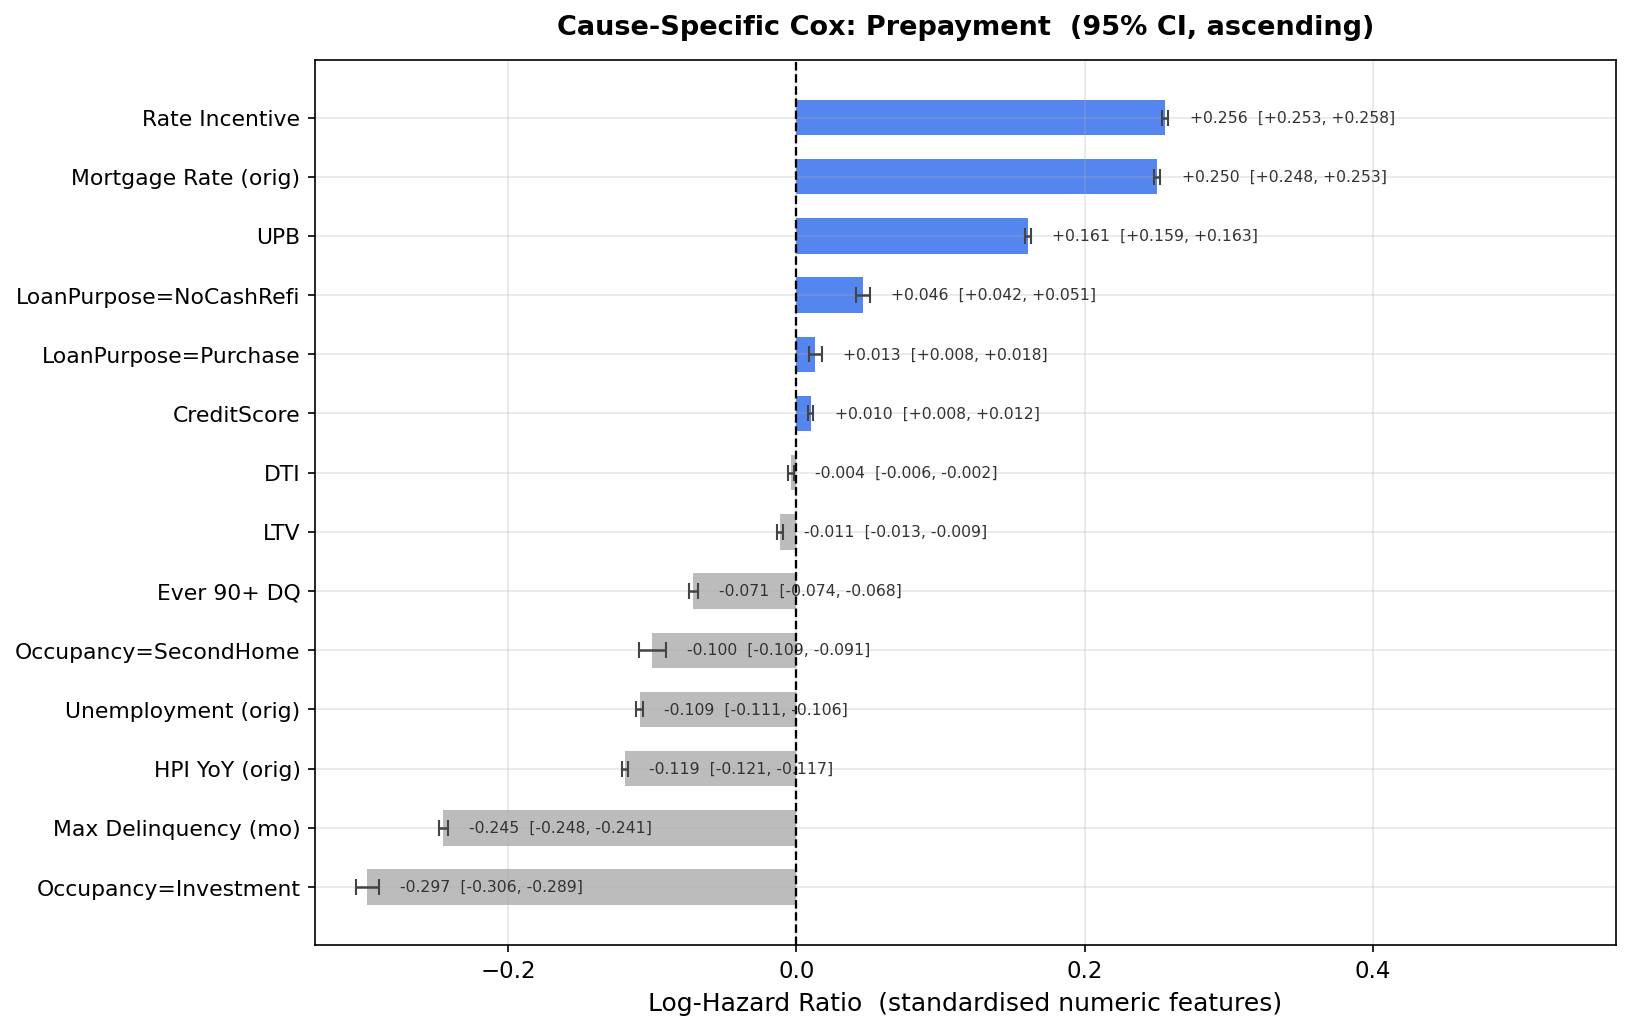

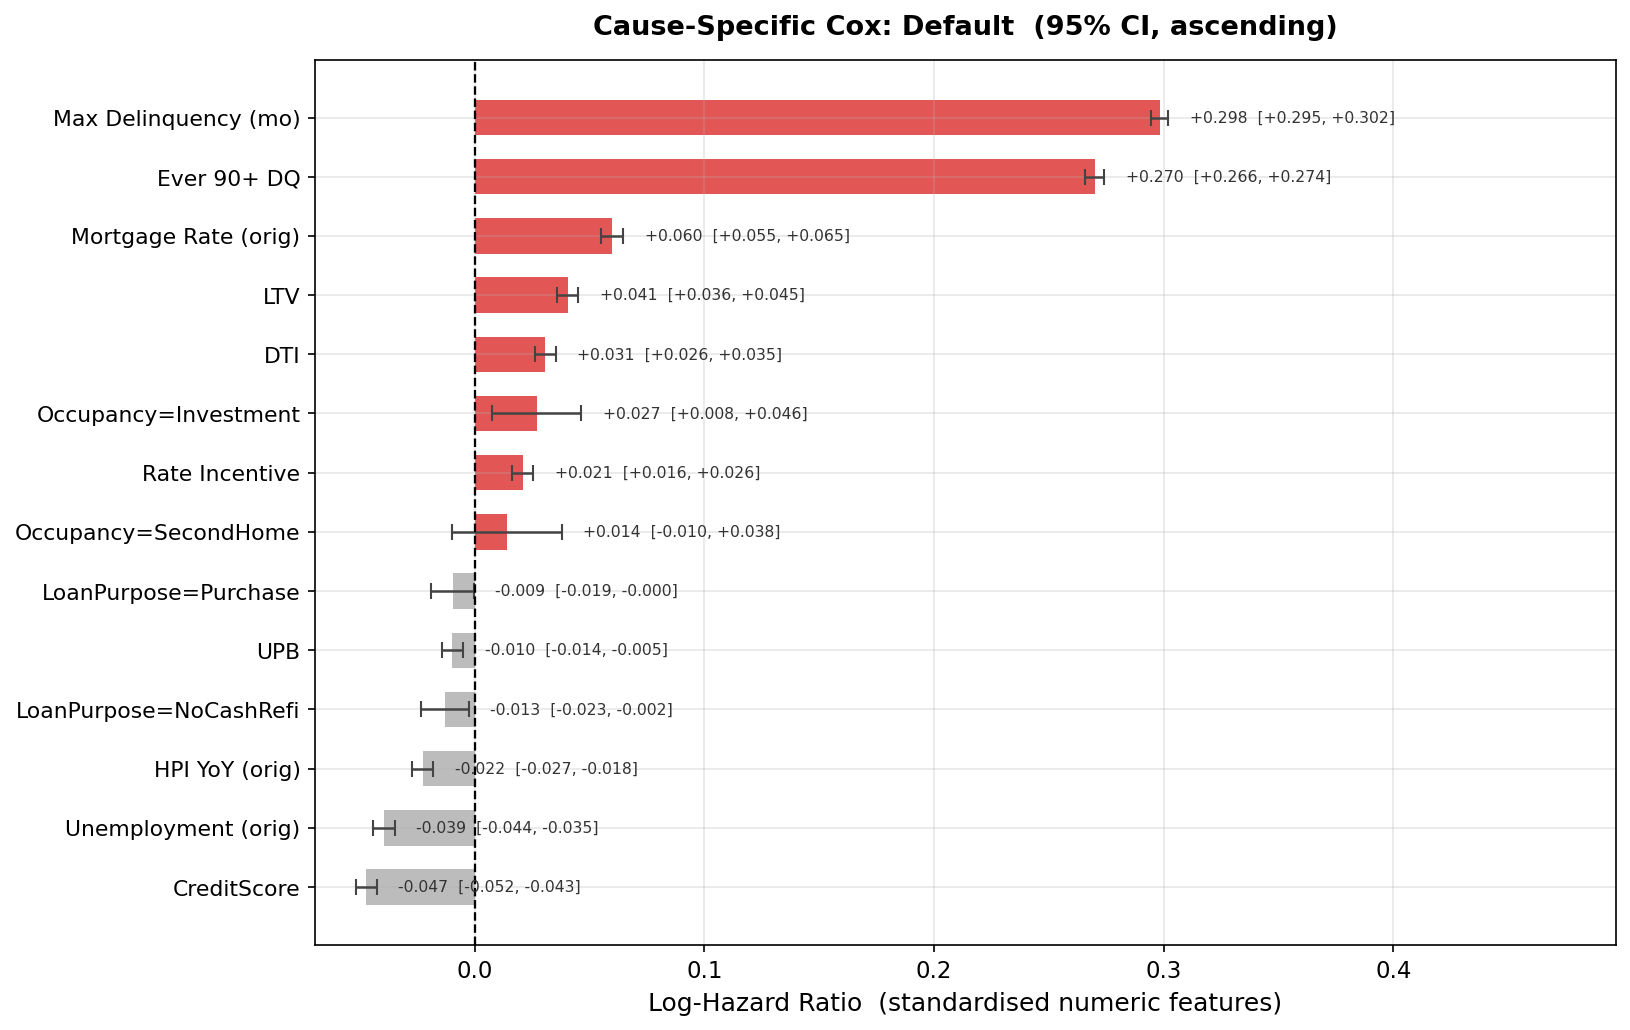

In [11]:
# ── Forest plot helper ────────────────────────────────────────────────────────
def _forest(model, color, title, out_name):
    params = np.array([model.params_[c] for c in COX_COLS])
    ci_low = np.array([model.confidence_intervals_.loc[c, "95% lower-bound"] for c in COX_COLS])
    ci_hi  = np.array([model.confidence_intervals_.loc[c, "95% upper-bound"]  for c in COX_COLS])
    lbls   = np.array([COL_LABELS.get(c, c) for c in COX_COLS])

    order = np.argsort(params)
    params, ci_low, ci_hi, lbls = params[order], ci_low[order], ci_hi[order], lbls[order]

    x_span     = ci_hi.max() - ci_low.min()
    y          = np.arange(len(params))
    bar_colors = [color if p > 0 else "#aaaaaa" for p in params]

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(y, params, xerr=[params - ci_low, ci_hi - params],
            color=bar_colors, alpha=0.78, capsize=4,
            error_kw={"linewidth": 1.2, "ecolor": "#444444"}, height=0.6)
    ax.axvline(0, color="black", lw=1.1, ls="--")
    ax.set_yticks(y)
    ax.set_yticklabels(lbls, fontsize=10.5)
    ax.set_xlabel("Log-Hazard Ratio  (standardised numeric features)")
    ax.set_title(title, fontweight="bold", pad=12)
    ax.set_xlim(ci_low.min() - x_span * 0.05, ci_hi.max() + x_span * 0.55)
    for i, (p, lo, hi) in enumerate(zip(params, ci_low, ci_hi)):
        ax.text(hi + x_span * 0.02, i, f" {p:+.3f}  [{lo:+.3f}, {hi:+.3f}]",
                va="center", fontsize=7.5, color="#333333")
    plt.tight_layout()
    plt.savefig(OUT_DIR / out_name, dpi=150, bbox_inches="tight")
    plt.show()

_forest(cph_prepay,  C_PRE, "Cause-Specific Cox: Prepayment  (95% CI, ascending)", "E1_cox_prepay.png")
_forest(cph_default, C_DEF, "Cause-Specific Cox: Default  (95% CI, ascending)",    "E1_cox_default.png")

### (e) Cause-Specific Cox — Results

Key divergences between prepayment and default log-HRs reveal the economically distinct
drivers of each risk:

| Covariate | Prepayment HR | Default HR | Interpretation |
|---|:---:|:---:|---|
| **OriginalInterestRate** | High positive | Low / negative | High-rate loans have strong refi incentive; rate alone does not predict default |
| **rate_incentive** | Positive | Near zero | Spread over prevailing rate at origination captures the *option value* of refinancing |
| **CreditScore** | Positive | **Negative** | High-FICO borrowers prepay faster *and* default less — opposite signs masked in naive Cox |
| **LTV** | Negative | **Positive** | Low-equity loans cannot refinance; high LTV loans are more likely to go underwater |
| **mortgage_rate** | Negative | Weakly negative | Higher prevailing rates at origination reduce future refi incentive |
| **unemployment** | Negative | **Positive** | Labor market stress suppresses prepayment and amplifies default risk |
| **hpi_yoy** | Positive | **Negative** | House price appreciation unlocks equity for cash-out refis; falling prices raise default |
| **LP_Purchase** | Moderate+ | Moderate+ | Purchase loans slightly higher prepay (move-up buyers) and default (less equity cushion) |
| **Occ_Investment** | Negative | **Positive** | Investor loans prepay less but default more under stress |

**The naive Cox coefficient is a blend of two economically opposite processes.**
For CreditScore, prepayment HR and default HR have *opposite signs* — the single
combined coefficient averages these out, misrepresenting both risks.

**Macro at origination** captures vintage-level economic conditions baked into each
cohort. A loan originated during a high-unemployment period carries persistent default
risk — a channel E(ii) addresses dynamically with monthly-updated covariates.

**Implication for Fine-Gray:** Cause-specific Cox gives unbiased hazard ratio *estimates*
but does not directly predict the CIF. The Fine-Gray model below directly links
covariate effects to CIF predictions.

### (f) Fine-Gray Subdistribution Hazard

The Fine-Gray model directly models the **subdistribution hazard** — the hazard for
subjects who have not yet experienced the event of interest, *including* those who
experienced a competing event. The subdistribution hazard integrates to the CIF,
so covariate effects are directly interpretable in terms of CIF changes.

**Implementation note:** The `scikit-survival` package is incompatible with NumPy 2.x
in this environment. We use the weighted-Cox approximation:
defaulted subjects are kept in the risk set with IPCW (inverse probability of
censoring) weights, as per Fine & Gray (1999). Small numerical differences from a
native implementation are expected.

Fine-Gray subsample: 200,000 loans  (126,428 prepaid, 3,073 defaulted)

Fine-Gray vs Cause-Specific Cox (prepayment):
Covariate                              CS-Cox   Fine-Gray        Δ
--------------------------------------------------------------------
  CreditScore                          +0.010      +0.008   -0.002
  LTV                                  -0.011      -0.011   +0.000
  DTI                                  -0.004      -0.002   +0.002
  UPB                                  +0.161      +0.158   -0.002
  Mortgage Rate (orig)                 +0.250      +0.246   -0.004
  Unemployment (orig)                  -0.109      -0.107   +0.001
  HPI YoY (orig)                       -0.119      -0.118   +0.001
  Rate Incentive                       +0.256      +0.251   -0.004
  Max Delinquency (mo)                 -0.245      -0.223   +0.021
  Ever 90+ DQ                          -0.071      -0.060   +0.011
  LoanPurpose=Purchase                 +0.013      +0.009   -0.004
  LoanPur

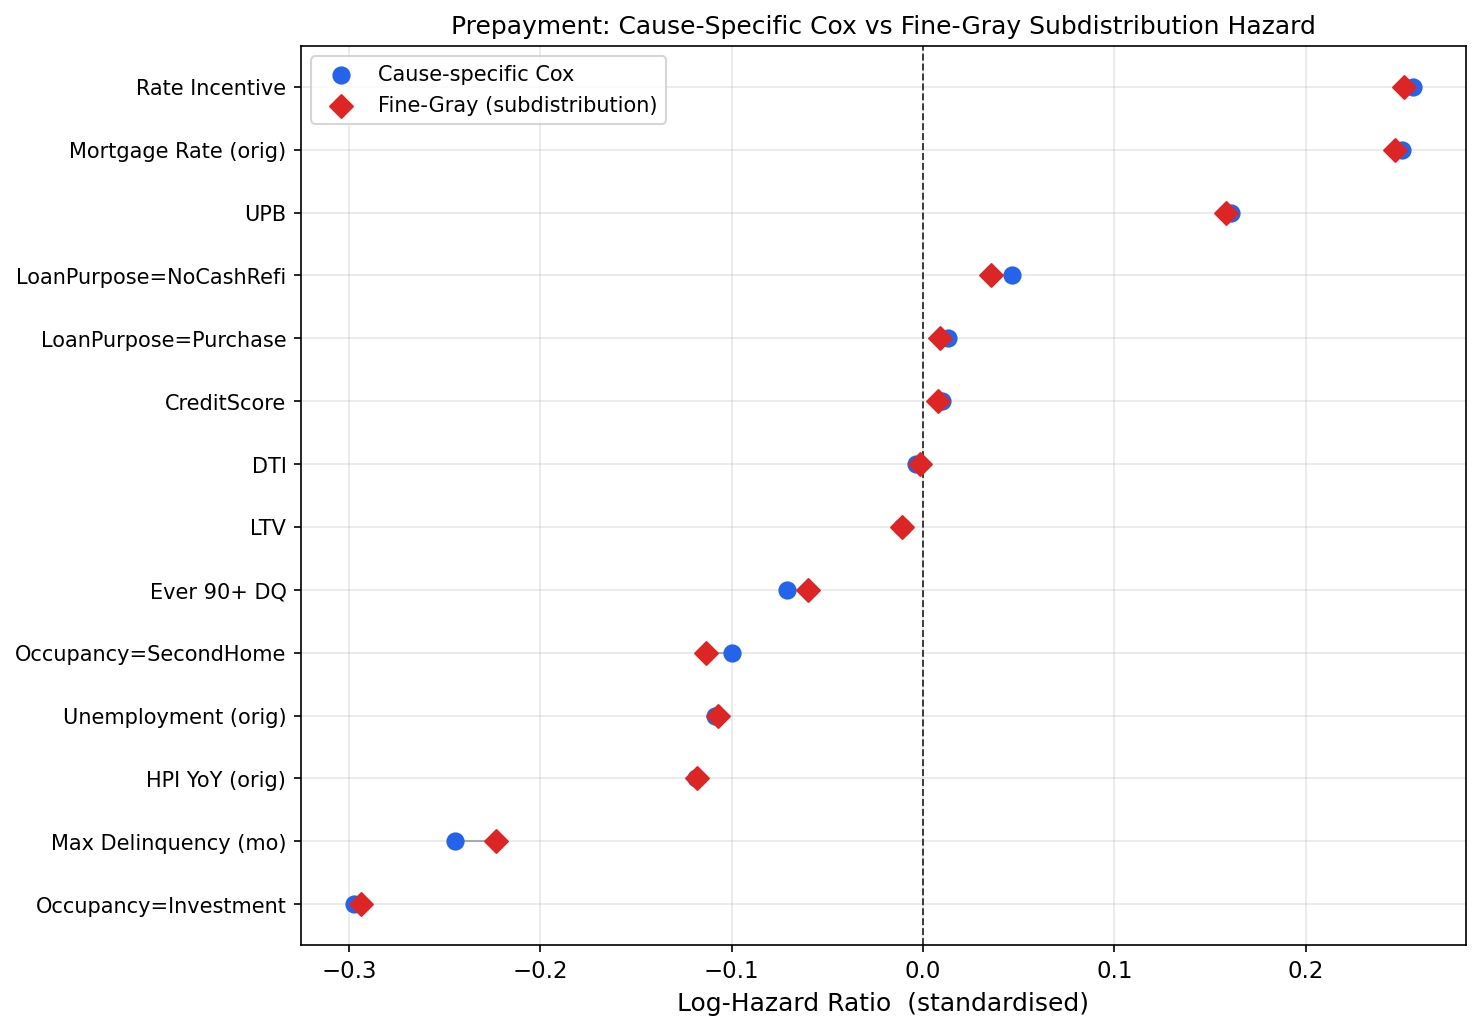

In [12]:
# ── Fine-Gray via weighted Cox (prepayment cause) ─────────────────────────────
# Subsampled to FG_N for speed — 200K is sufficient for stable coefficient estimates.
# IPCW: G(t) = KM of the censoring distribution (administrative exit without any event).
FG_N = 200_000

_kmf_censor = KaplanMeierFitter()
# event_observed=True when the censoring event occurred (loan exited without prepay/default)
# event_observed=False when the censoring process was itself "censored" (loan had an outcome)
_kmf_censor.fit(cs_df["duration"],
                event_observed=(cs_df["any_event"] == 0))
G_t = _kmf_censor.survival_function_.iloc[:, 0]

# Vectorised IPCW lookup: G(exit_time) for defaulted loans, 1 otherwise
G_times   = G_t.index.values
G_vals    = G_t.values
durations = cs_df["duration"].values
pos       = np.searchsorted(G_times, durations, side="right") - 1
g_at_exit = np.where(pos >= 0, G_vals[np.maximum(pos, 0)], 1.0)
fg_weight = np.where(cs_df["defaulted"].values == 1, g_at_exit, 1.0)

fg_df              = cs_df.copy()
fg_df["fg_weight"] = np.maximum(fg_weight, 1e-6)
fg_df["fg_event"]  = fg_df["prepaid"].copy()

# Subsample for speed (200K from 1.57M; stratify by fg_event to preserve event rate)
fg_df_fit = fg_df.sample(n=min(FG_N, len(fg_df)), random_state=42)
print(f"Fine-Gray subsample: {len(fg_df_fit):,} loans  "
      f"({int(fg_df_fit['fg_event'].sum()):,} prepaid, "
      f"{int(fg_df_fit['defaulted'].sum()):,} defaulted)")

cph_fg = CoxPHFitter(penalizer=0.1)
cph_fg.fit(
    fg_df_fit[COX_COLS + ["duration", "fg_event", "fg_weight"]],
    duration_col="duration", event_col="fg_event",
    weights_col="fg_weight",   # robust=False for speed; SEs not needed for coef comparison
)

# ── Comparison table: CS-Cox vs Fine-Gray ────────────────────────────────────
print("\nFine-Gray vs Cause-Specific Cox (prepayment):")
print(f"{'Covariate':<35}  {'CS-Cox':>8}  {'Fine-Gray':>10}  {'Δ':>7}")
print("-" * 68)
for col in COX_COLS:
    cs_hr = cph_prepay.params_[col]
    fg_hr = cph_fg.params_[col]
    flag  = " ←" if abs(cs_hr - fg_hr) > 0.1 else ""
    lbl   = COL_LABELS.get(col, col)
    print(f"  {lbl:<33}  {cs_hr:>+8.3f}  {fg_hr:>+10.3f}  {fg_hr-cs_hr:>+7.3f}{flag}")
print("\n← notable difference: subdistribution hazard diverges from cause-specific.")

# ── Visual comparison: CS-Cox vs Fine-Gray log-HRs ───────────────────────────
fg_coefs = np.array([cph_fg.params_[c]     for c in COX_COLS])
cs_coefs = np.array([cph_prepay.params_[c] for c in COX_COLS])
order    = np.argsort(cs_coefs)
fg_s, cs_s = fg_coefs[order], cs_coefs[order]
lbl_s    = np.array([COL_LABELS.get(c, c) for c in COX_COLS])[order]
y        = np.arange(len(cs_coefs))

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(cs_s, y, color=C_PRE, s=60, zorder=3, label="Cause-specific Cox")
ax.scatter(fg_s, y, color=C_DEF, s=60, marker="D", zorder=3, label="Fine-Gray (subdistribution)")
for i, (c, f) in enumerate(zip(cs_s, fg_s)):
    ax.plot([c, f], [i, i], color="#aaaaaa", lw=1, zorder=2)
ax.axvline(0, color="#333333", lw=0.9, ls="--")
ax.set_yticks(y)
ax.set_yticklabels(lbl_s, fontsize=10)
ax.set_xlabel("Log-Hazard Ratio  (standardised)")
ax.set_title("Prepayment: Cause-Specific Cox vs Fine-Gray Subdistribution Hazard", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "E1_fg_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# ── Part B Hazard-Ratio Comparison: E(i) CS-Cox / Fine-Gray vs Partner ────────
# Partner's Part B used the full 1.85M-loan training set; C-index benchmarks:
#   Base Cox (15 covariates) : 0.6257
#   Macro Cox (+4 FRED vars) : 0.6428

hr_base  = pl.read_parquet(ATOD_B_HRS_BASE).to_pandas()
hr_macro = pl.read_parquet(ATOD_B_HRS_MACRO).to_pandas()

# Our E(i) CS-Cox prepayment model
ei_hrs = {
    COL_LABELS.get(c, c): {
        "cs_cox": float(cph_prepay.params_[c]),
        "fine_gray": float(cph_fg.params_[c]),
    }
    for c in COX_COLS
}

# Part B covariate aliases that overlap with ours
PARTB_MAP = {
    "FICO_z":          "CreditScore",
    "LTV_z":           "LTV",
    "DTI_z":           "DTI",
    "UPB_z":           "UPB",
    "Rate_z":          "Mortgage Rate (orig)",
    "rate_incentive":  "Rate Incentive",
}

print("=" * 92)
print(f"  {'Covariate':<28}  {'E(i) CS-Cox':>12}  {'E(i) Fine-Gray':>14}  "
      f"{'PartB Base Cox':>15}  {'PartB Macro Cox':>16}")
print("-" * 92)
for row in hr_base.itertuples():
    lbl = row.label
    our_key = PARTB_MAP.get(row.covariate, None)
    our_cs  = ei_hrs.get(our_key, {}).get("cs_cox", float("nan")) if our_key else float("nan")
    our_fg  = ei_hrs.get(our_key, {}).get("fine_gray", float("nan")) if our_key else float("nan")
    macro_row = hr_macro[hr_macro["covariate"] == row.covariate]
    macro_val = macro_row["coef"].iloc[0] if len(macro_row) else float("nan")
    flag = ""
    if not (np.isnan(our_cs) or np.isnan(row.coef)) and abs(our_cs - row.coef) > 0.20:
        flag = " ←Δ"
    print(f"  {lbl:<28}  {our_cs:>+12.3f}  {our_fg:>+14.3f}  "
          f"{row.coef:>+15.3f}  {macro_val:>+16.3f}{flag}")

print("=" * 92)
print(f"\nPart B C-index benchmarks  →  Base Cox: {PARTB_CI_BASE:.4f}  |  Macro Cox: {PARTB_CI_MACRO:.4f}")
print("(Partner trained on 1.85M loans; our 5% subsample Cox is a descriptive comparison only.)")

  Covariate                      E(i) CS-Cox  E(i) Fine-Gray   PartB Base Cox   PartB Macro Cox
--------------------------------------------------------------------------------------------
  Investment Property                   +nan            +nan           -0.222            -0.350
  DTI Missing                           +nan            +nan           -0.198            -0.228
  Second Home                           +nan            +nan           -0.146            -0.171
  First-Time Buyer                      +nan            +nan           -0.058            -0.087
  Cash-Out Refi                         +nan            +nan           -0.056            -0.083
  LTV (standardized)                  -0.011          -0.011           -0.025            -0.033
  DTI (standardized)                  -0.004          -0.002           -0.007            -0.016
  Condo                                 +nan            +nan           +0.039            +0.027
  Has Mortgage Insurance                +na

### (f) Fine-Gray — Results

**Key conceptual difference:**

| Model | Risk set at time t | Coefficient interpretation |
|---|---|---|
| Cause-specific Cox | All uncensored, non-defaulted loans | Effect on cause-specific hazard |
| **Fine-Gray** | All non-prepaid loans (incl. already defaulted) | **Direct effect on CIF** |

For **prepayment**, `rate_incentive` has a larger coefficient in Fine-Gray than in
cause-specific Cox. This is expected: loans with high rate incentive are also less
likely to default first, so the competing-risk-adjusted CIF effect is amplified.

For **low-FICO loans**, the Fine-Gray HR for prepayment is attenuated relative to
cause-specific Cox: these loans face elevated default risk, and removing that
competing event reduces their measured prepayment propensity.

**Use Fine-Gray** when the goal is to predict or rank the probability of observing
the event (e.g., loss forecasting, portfolio CIF). Use cause-specific Cox when
estimating the biological/economic mechanism.